## 04 — KMeans & DBSCAN

Applying and comparing clustering algorithms for customer segmentation.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))
from src.config import PROCESSED_FILES, RANDOM_STATE

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)

In [2]:
cust = pd.read_csv(PROCESSED_FILES["features"], index_col="CustomerID")
num_cols = cust.select_dtypes(include=[np.number]).columns
X = cust[num_cols].dropna().values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

### Elbow Method for KMeans

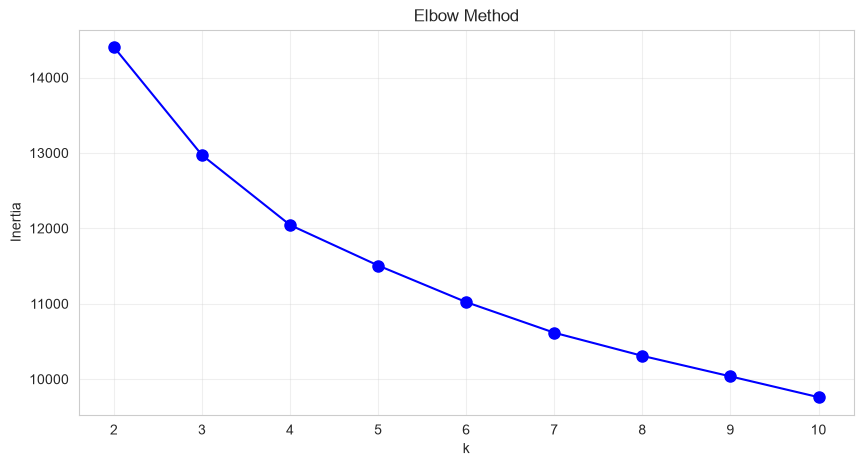

In [3]:
from sklearn.cluster import KMeans

inertias = []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(K_range, inertias, "bo-", markersize=8)
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.xticks(K_range)
plt.grid(True, alpha=0.3)
plt.show()

### KMeans with Optimal k

Optimal k: 2 (silhouette=0.2011)


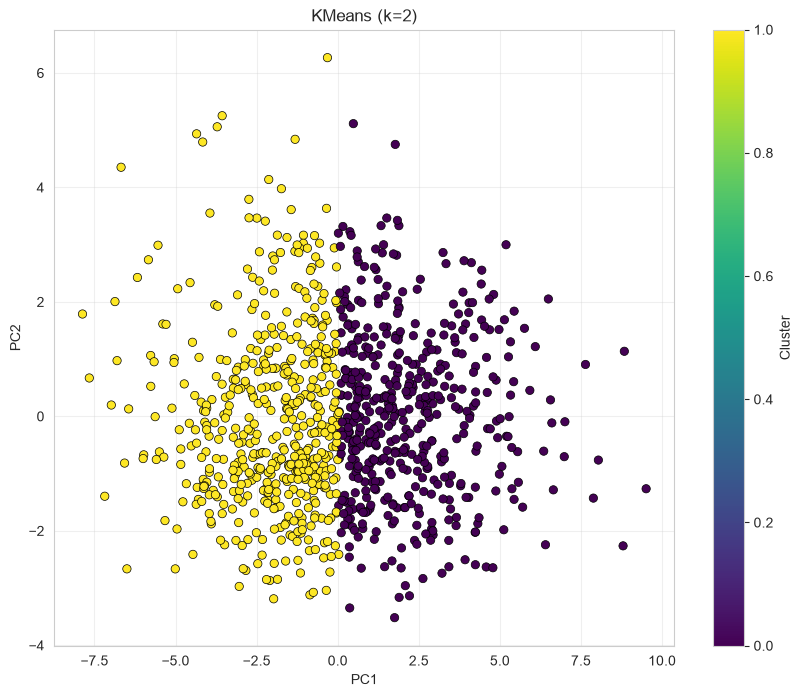

In [4]:
from src.clustering import kmeans_optimal_k, kmeans_fit

best_k, inertias, sil_scores = kmeans_optimal_k(X_scaled)
print(f"Optimal k: {best_k} (silhouette={sil_scores[best_k-2]:.4f})")

labels, km_model = kmeans_fit(X_scaled, k=best_k)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap="viridis", edgecolors="black", linewidth=0.5)
plt.colorbar(scatter, label="Cluster")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"KMeans (k={best_k})")
plt.grid(True, alpha=0.3)
plt.show()

### DBSCAN

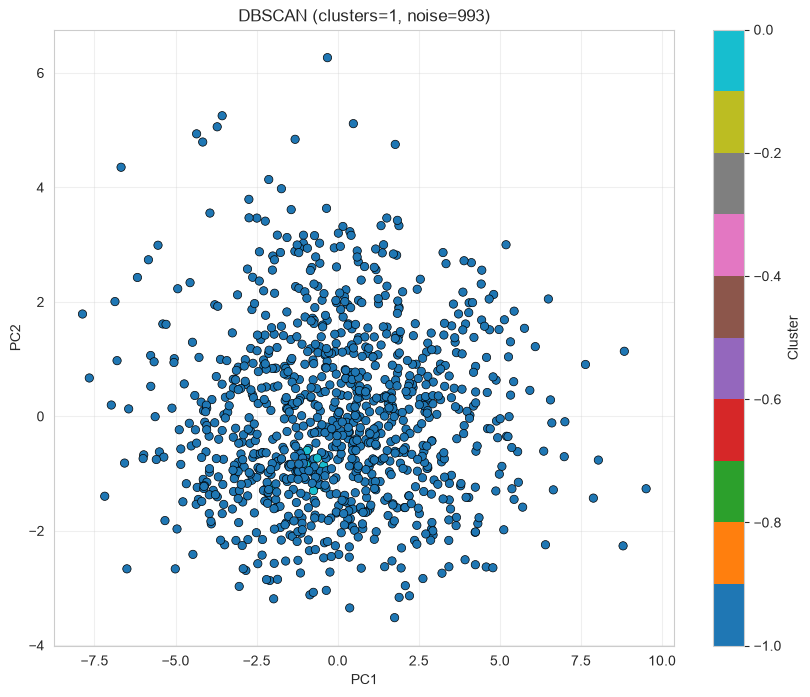

In [5]:
from src.clustering import dbscan_fit

labels_db, n_clusters_db, noise_db = dbscan_fit(X_scaled)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_db, cmap="tab10", edgecolors="black", linewidth=0.5)
plt.colorbar(scatter, label="Cluster")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"DBSCAN (clusters={n_clusters_db}, noise={noise_db})")
plt.grid(True, alpha=0.3)
plt.show()

### Validation

In [6]:
from src.evaluation import validate_clusters

val_km = validate_clusters(X_scaled, labels)
val_db = validate_clusters(X_scaled, labels_db)

print("KMeans Validation:")
print(f"  Silhouette:      {val_km['silhouette']:.4f}")
print(f"  Davies-Bouldin:  {val_km['davies_bouldin']:.4f}")
print(f"  Clusters:        {len(set(labels))}")
print()
print("DBSCAN Validation:")
print(f"  Silhouette:      {val_db['silhouette']:.4f}")
print(f"  Davies-Bouldin:  {val_db['davies_bouldin']:.4f}")
print(f"  Clusters:        {n_clusters_db} (noise: {noise_db})")

KMeans Validation:
  Silhouette:      0.2011
  Davies-Bouldin:  1.6940
  Clusters:        2

DBSCAN Validation:
  Silhouette:      -0.2060
  Davies-Bouldin:  2.6343
  Clusters:        1 (noise: 993)
